# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- State extraction
- Utility experiment


## 1. Load DuckDB and build weekly counts


DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\commitizen.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\ocel2_commitizen.sqlite


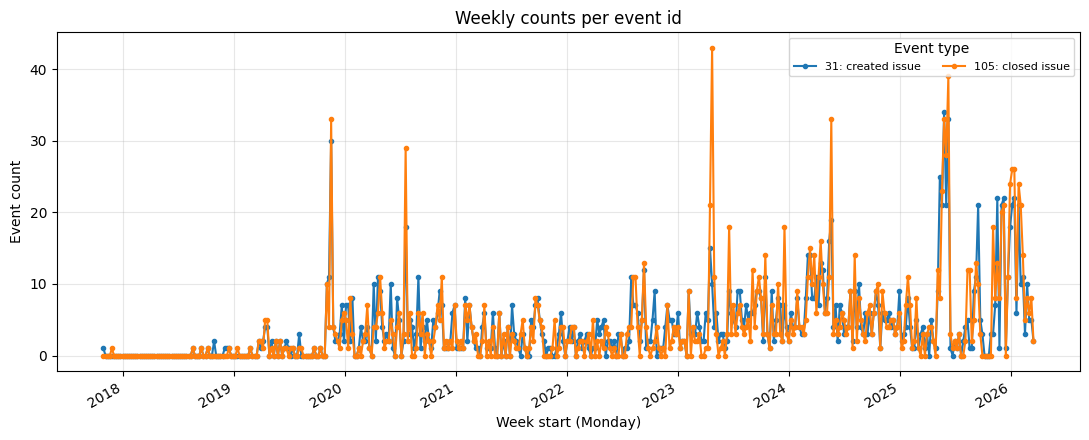

event_type_id,31,105
week_start,,
2017-10-30,1,0
2017-11-27,0,1
2018-08-20,1,1
2018-09-17,1,1
2018-10-08,1,1


In [2]:
from pathlib import Path

from functions.config import (
    COMMITIZEN_DUCKDB,
    OCEL2_SQLITE,
    RESULTS_FIGURES,
    RESULTS_TABLES,
)
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import plot_weekly_event_counts

RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)

print("DuckDB:", COMMITIZEN_DUCKDB)
print("OCEL2:", OCEL2_SQLITE)

eventsPerobj_df = load_events_per_obj()
objects_attributes = load_objects_attributes()
weekly = build_weekly_issue_counts(eventsPerobj_df)
plot_weekly_event_counts(weekly)
weekly.head()


## 2. Rolling IQR + lexicon state extraction


In [3]:
from functions.anomaly_pipeline import run_anomaly_state_extraction

weekly_105_anomaly_frame, anomaly_context, anomaly_states, event_105_title_join = (
    run_anomaly_state_extraction(weekly, eventsPerobj_df, objects_attributes)
)
anomaly_states.head()


Detected 25 rolling-IQR anomalies for event_type_id=105.
Joined title attribute rows: 1729 of 1729 event rows.
Saved anomaly states to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\anomaly_states.csv


,week_start,value,is_anomaly,anomaly_direction,anomaly_score,lower_bound,upper_bound,title_count,event_count,severity,component,reasoning,extraction_method,confidence,event_descriptions,titles_in_week
0,2019-04-15,5,True,high,3.833333,-0.875,2.125,5,5,P4,documentation,Weekly closures show a well beyond-typical spi...,rule_based,0.736905,"[closed (#19), closed (#15), closed (#17), clo...","[fix(bump): prefixes like docs, build, etc no ..."
1,2019-04-22,5,True,high,6.500000,-0.250,1.750,4,5,P4,version & bump,Weekly closures show a well beyond-typical spi...,rule_based,0.688929,"[closed (#23), closed (#20), closed (#21), clo...",[fix(bump): handle commit and create tag failu...
2,2019-05-20,2,True,high,0.000000,1.000,1.000,2,2,P3,dependencies,Weekly closures show a near-typical spike (2 v...,rule_based,0.772500,"[closed (#26), closed (#27)]",[chore(deps-dev): update black requirement fro...
3,2019-11-04,10,True,high,0.000000,1.000,1.000,10,10,P3,build & ci,Weekly closures show a near-typical spike (10 ...,rule_based,0.664167,"[closed (#32), closed (#41), closed (#7), clos...","[Handle git tag failure, feat(commit): new ret..."
4,2019-11-11,4,True,high,0.000000,1.000,1.000,4,4,P2,build & ci,Weekly closures show a near-typical spike (4 v...,rule_based,0.550417,"[closed (#46), closed (#51), closed (#50), clo...",[Exception occurs when subject is not provided...


## 3. Export anomaly object / event IDs


In [4]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(anomaly_context)
anomaly_object_ids.head()



,week_start,object_id
0,2019-04-15,116370
1,2019-04-15,116396
2,2019-04-15,116442
3,2019-04-15,116518
4,2019-04-15,116547


## 4. Anomaly plots


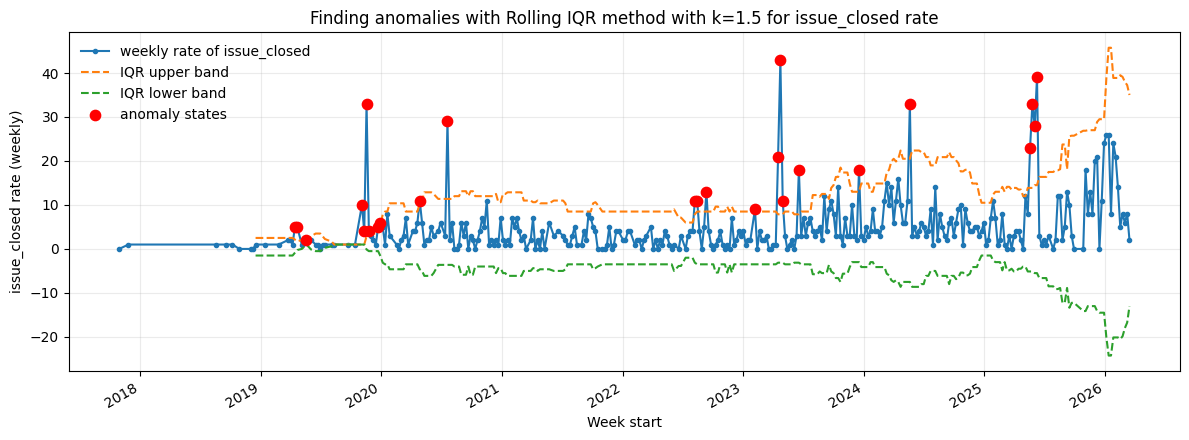

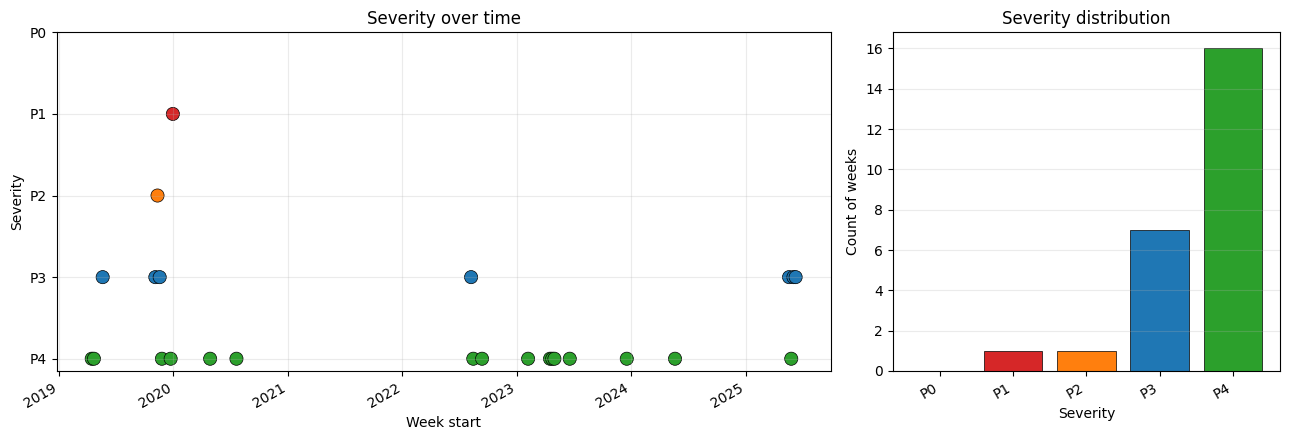

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:310: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 1])


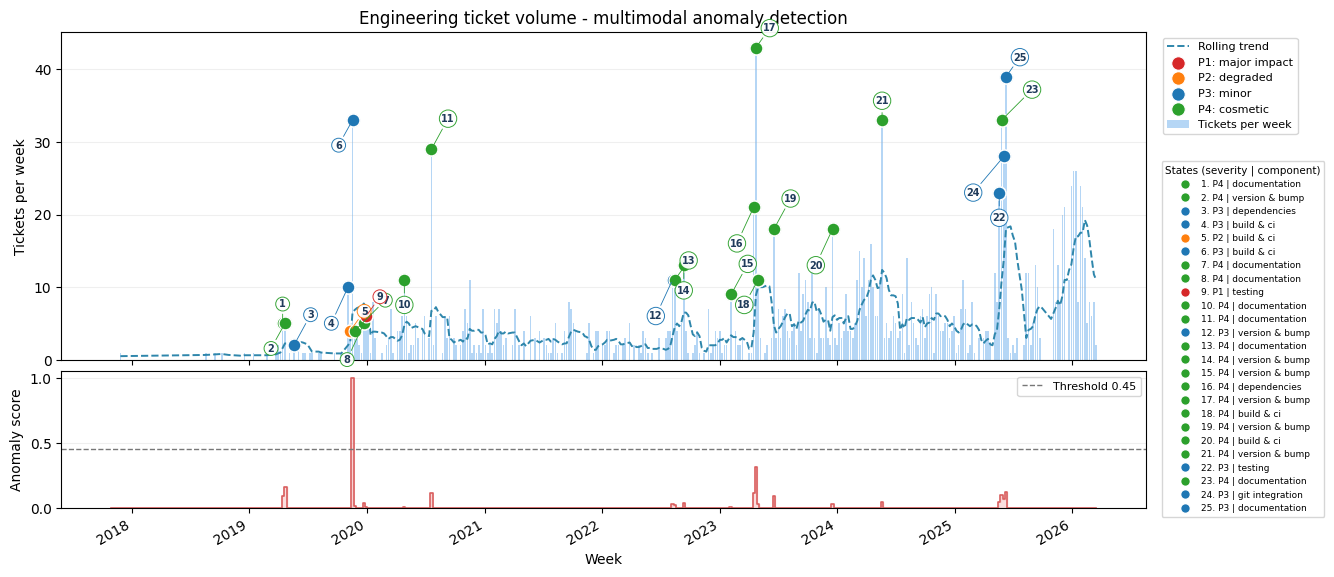

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:426: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 0.985])


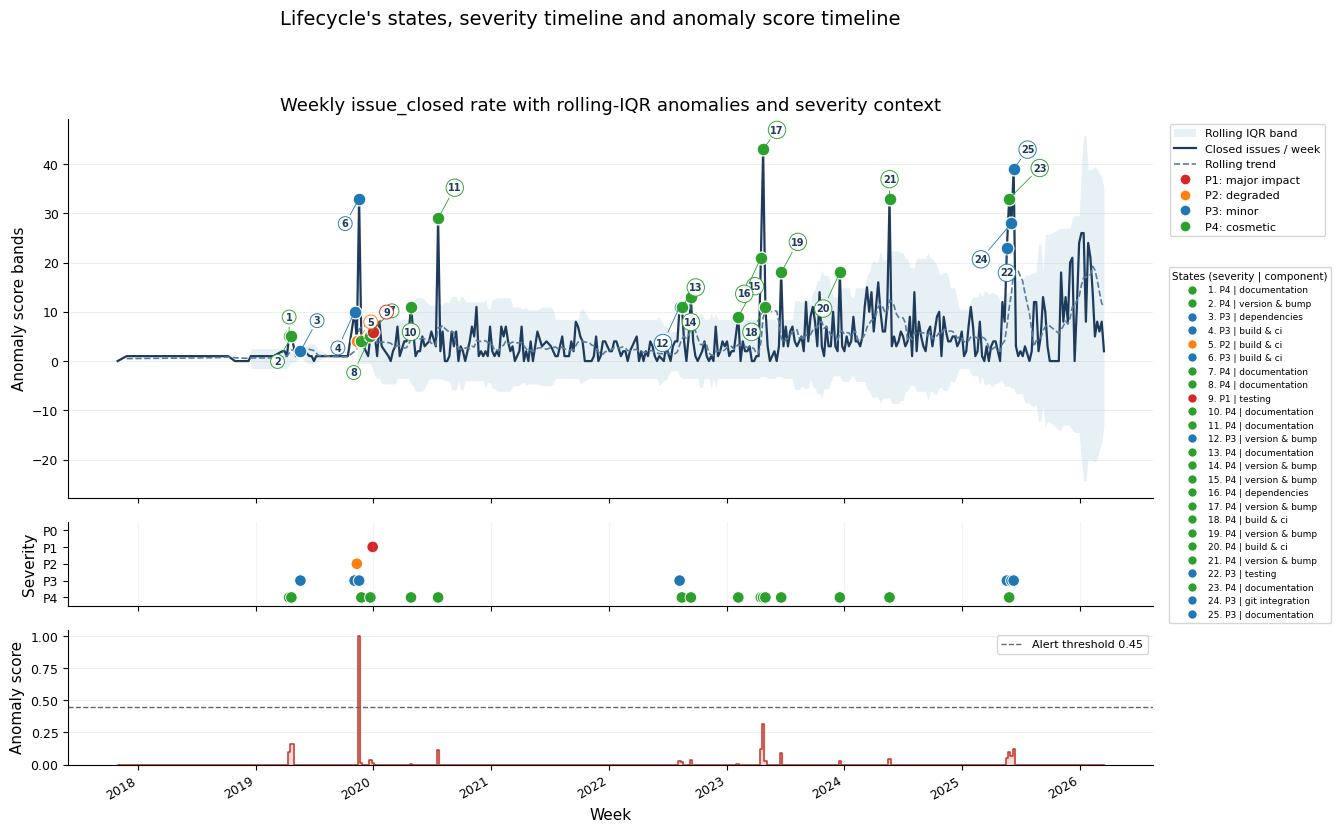

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures')

In [6]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(weekly_105_anomaly_frame, anomaly_states)


## 5. Commit context and type classification


In [ ]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_43_message_join = build_commit_context(
    weekly_105_anomaly_frame, eventsPerobj_df, objects_attributes
)
commit_typeclass_per_week = build_commit_typeclass(commit_context)
plot_commit_category_stack(commit_context, commit_typeclass_per_week)


## 6. Flatten OCEL2 issue log


In [ ]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log()


## 7. Vitalizing subset from anomaly object IDs


In [ ]:
from functions.ocel_flatten import build_vitalizing_subset

anomaly_events_df, anomaly_df = build_vitalizing_subset(flat, anomaly_object_ids)


## 8. Preprocess + random control (MAX_REP / SEED unchanged)


In [ ]:
from functions.preprocessing import build_preprocessed_logs

prep = build_preprocessed_logs(flat, anomaly_events_df)
flat_df_clean = prep["flat_df_clean"]
vitalizing_df_clean = prep["vitalizing_df_clean"]
random_case_control_df_clean = prep["random_case_control_df_clean"]
clean_log_groups_df = prep["clean_log_groups_df"]
all_cases_clean = prep["all_cases_clean"]
num_vital_cases_clean = prep["num_vital_cases_clean"]


## 9. Discovery F1 evaluation on clean logs


In [ ]:
from functions.discovery import evaluate_clean_logs

consolidated_results_table_clean, clean_log_groups_eventlog, miners = evaluate_clean_logs(
    clean_log_groups_df
)
consolidated_results_table_clean.head()


## 10. Utility figures


In [ ]:
from functions.plotting_utility import plot_utility_figures

plot_utility_figures(consolidated_results_table_clean)


## 11. Log complexity metrics (process-complexity / EPA)


In [ ]:
from functions.complexity_metrics import compute_log_complexity_table

log_complexity_similarity_table = compute_log_complexity_table(clean_log_groups_eventlog)
log_complexity_similarity_table


## 12. Seed reproducibility


In [ ]:
from functions.plotting_utility import plot_repro_slopegraph
from functions.reproducibility import run_seed_reproducibility

repro = run_seed_reproducibility(
    flat_df_clean=flat_df_clean,
    all_cases_clean=all_cases_clean,
    num_vital_cases_clean=num_vital_cases_clean,
    miners=miners,
    consolidated_results_table_clean=consolidated_results_table_clean,
)
consolidated_results_table_clean_repro = repro["consolidated_results_table_clean_repro"]
plot_repro_slopegraph(consolidated_results_table_clean_repro)
